In [1]:
# ============================================================
# Titanic ML Project
# Notebook 01: Exploratory Data Analysis
# ============================================================

#Import libraries
import pandas as pd
import numpy as np

#load in csv data as pandas dataframe
df = pd.read_csv("../data/train.csv")

#first look at the data frame
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:", df.columns.tolist())


#testing the import of csv and first looks
print("\n\nFirst 5 rows:")
df.head()

Shape of dataset:
(891, 12)

Column names: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
#Get a summary of every column

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
#basic stats for every numeric column
df.describe()

#After running: Found out that there is around 177 people unaccounted for their age
#Cabin is missing for 687 people - data cleaning time

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# "What percentage of passengers survived?"
# How many people survived vs died 
print("Survival Counts:")
print(df["Survived"].value_counts())


print("\nSurvival rate:")
print(df['Survived'].value_counts(normalize=True).round(2))


Survival Counts:
Survived
0    549
1    342
Name: count, dtype: int64

Survival rate:
Survived
0    0.62
1    0.38
Name: proportion, dtype: float64


In [5]:
'''
Gender correlation to survival
Question: Did men or women survive more?
'''

print(df.groupby('Sex')['Survived'].mean().round(2))

Sex
female    0.74
male      0.19
Name: Survived, dtype: float64


In [6]:
# Did ticket class affect survival rate?
print("Survival rate by passenger class:")
print(df.groupby('Pclass')['Survived'].mean().round(2))

# Count of passengers in each class
print("\nPassenger count per class:")
print(df['Pclass'].value_counts().sort_index())

Survival rate by passenger class:
Pclass
1    0.63
2    0.47
3    0.24
Name: Survived, dtype: float64

Passenger count per class:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64


In [7]:
# Age distribution and survival
# ----------------------------------------

print("Age Stats for ALL passengers:")
print(df['Age'].describe().round(2))

print("\nAge statistics — SURVIVORS only:")
print(df[df['Survived'] == 1]['Age'].describe().round(2))

print("\nAge statistics — NON-SURVIVORS only:")
print(df[df['Survived'] == 0]['Age'].describe().round(2))


Age Stats for ALL passengers:
count    714.00
mean      29.70
std       14.53
min        0.42
25%       20.12
50%       28.00
75%       38.00
max       80.00
Name: Age, dtype: float64

Age statistics — SURVIVORS only:
count    290.00
mean      28.34
std       14.95
min        0.42
25%       19.00
50%       28.00
75%       36.00
max       80.00
Name: Age, dtype: float64

Age statistics — NON-SURVIVORS only:
count    424.00
mean      30.63
std       14.17
min        1.00
25%       21.00
50%       28.00
75%       39.00
max       74.00
Name: Age, dtype: float64


In [8]:
# Create age groups to spot patterns more clearly
df['AgeGroup'] = pd.cut(df['Age'],
                        bins = [0,12,18,35,60,100],
                        labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])

print("Survival rate by age group:")
print(df.groupby('AgeGroup', observed=True)['Survived'].mean().round(2))

print("\nPassenger count per age group:")
print(df['AgeGroup'].value_counts().sort_index())

Survival rate by age group:
AgeGroup
Child         0.58
Teen          0.43
YoungAdult    0.38
Adult         0.40
Senior        0.23
Name: Survived, dtype: float64

Passenger count per age group:
AgeGroup
Child          69
Teen           70
YoungAdult    358
Adult         195
Senior         22
Name: count, dtype: int64


In [12]:
#What happens when we combine sex + passenger class [Pclass]
print('Survival rate by sex and Pclass')
print(df.groupby(['Sex', 'Pclass'])['Survived'].mean().round(2))


Survival rate by sex and Pclass
Sex     Pclass
female  1         0.97
        2         0.92
        3         0.50
male    1         0.37
        2         0.16
        3         0.14
Name: Survived, dtype: float64


In [18]:
# =========================
# POINT 3 — Visualizations
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# Makes charts appear inside the notebook and not make a new tab/window for it
%matplotlib inline

# setting the visual style for all charts
sns.set_style("whitegrid") #Sets a clean white background with grid lines for all charts
plt.rcParams['figure.figsize'] = (10, 6) #Sets default chart size to 10 wide, 6 tall (inches)
plt.rcParams['font.size'] = 12 #Sets default text size to 12

print("Matplotlib and Seaborn loaded!")


Matplotlib and Seaborn loaded!


C:\Users\haris\AppData\Local\Temp\ipykernel_16220\1754690908.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Survived', palette=['#d9534f', '#5cb85c'], ax=ax)


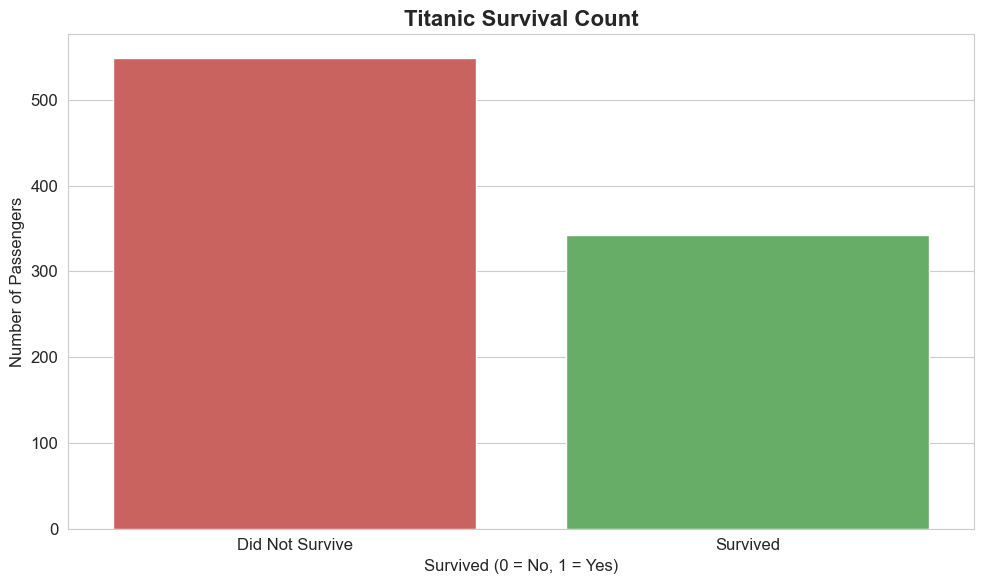

Chart saved to outputs folder!


In [22]:
# Chart 1: How many survived vs died?

fig, ax = plt.subplots() #Create blank canvas

sns.countplot(data=df, x='Survived', palette=['#d9534f', '#5cb85c'], ax=ax)

ax.set_title('Titanic Survival Count', fontsize=16, fontweight='bold')
ax.set_xlabel('Survived (0 = No, 1 = Yes)')
ax.set_ylabel('Number of Passengers')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Did Not Survive', 'Survived'])

plt.tight_layout()
plt.savefig('../outputs/01_survival_count.png', dpi=150)
plt.show()

print("Chart saved to outputs folder!")


## Key Findings So Far

### Finding 1 — Gender
- Female survival rate: 74%
- Male survival rate: 19%
- Women were ~4x more likely to survive
- Reason: "Women and children first" policy strictly followed by crew

### Finding 2 — Passenger Class
- 1st class survival rate: ~63%
- 2nd class survival rate: ~47%
- 3rd class survival rate: ~24%
- Reason: cabin location, lifeboat access, crew notification, social class bias

### Finding 3 — Age
- Mean age of survivors: 28.34 vs non-survivors: 30.63
- Children (0-12) had highest survival rate: 58%
- Seniors (60+) had lowest survival rate: 23%
- "Children first" policy confirmed in data
- Caution: Senior sample size only 22 passengers


### Initial Hypothesis
Survival was heavily influenced by Sex and Pclass.
These will likely be our strongest predictive features in the ML model.